# Closing surface forcing budgets

To properly diagnose changes in sea ice and surface heat fluxes we need to ba able to separate heat and freshwater fluxes used for sea ice formation.

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean as cm
import glob
import matplotlib.colors as col
import cf_xarray as cf
# need to install opencv-python for this:
import cv2
import warnings
import logging
from scipy.ndimage import distance_transform_edt
import scipy.ndimage as nd
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation
import imageio.v3 as iio
import glob
import imageio.v3 as iio
import cmocean.cm as cm

logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client


In [2]:
client = Client(threads_per_worker = 1)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

importing surface fluxes data

In [3]:
ocean_daily = xr.open_dataset('/scratch/oz91/wf4500/Panan01_extension_18Nov2025/wf4500/mom6/archive/mom6-panan-panan-01-1ac3e236/output001/20010101.ocean_daily_2001_001.nc')
ocean_static = xr.open_dataset('/scratch/oz91/wf4500/Panan01_extension_18Nov2025/wf4500/mom6/archive/mom6-panan-panan-01-1ac3e236/output001/20010101.ocean_static.nc')
ice_daily = xr.open_dataset('/scratch/oz91/wf4500/Panan01_extension_18Nov2025/wf4500/mom6/archive/mom6-panan-panan-01-1ac3e236/output001/20010101.ice_daily.nc')
#areacello for sea ice
areacello_SI = ocean_static.areacello.rename({'xh':'xT','yh':'yT'})
areacello_SI['xT'] = ice_daily.xT
areacello_SI['yT'] = ice_daily.yT

### Freshwater fluxes balance

Let's try to close the freshwater fluxes balance, and see how the fluxes go together to sum up to the wfo term

In [4]:
#horizontally integrated surface fluxes
#separating fluxes
ocean_daily_fluxes = ocean_daily.drop(('net_fresh_water_global_adjustment','salt_flux_global_restoring_adjustment',\
                                      'vprec_global_adjustment','total_icemelt','umo_2d','vmo_2d','tauuo','tauvo','T_adx_2d','T_ady_2d',\
                                      'average_T1','average_T2','average_DT','time_bnds','scalar_axis')).isel(time=0).drop('time')
#horizontally integrating fluxes
ocean_daily_int = (ocean_daily_fluxes *ocean_static.areacello).sum(('xh','yh')) # [kg/s], horizontally integrated
#for sanity check
wf0_int = (ocean_daily.wfo *ocean_static.areacello).isel(time=0).sum(('xh','yh')) # kg/s

#output ot sanity check
message = 'Horizontal integration was correctly done' if ocean_daily_int.wfo==wf0_int else 'Horizontal integration is wrong!'
print(message)

Horizontal integration was correctly done


In [5]:
#Converting practical to absolute salinity
from gsw import SA_from_SP
from gsw import p_from_z

ocean_daily_lat =(1+(ocean_daily.sos *0)) * ocean_daily.yh
ocean_daily_lon =(1+(ocean_daily.sos *0)) * ocean_daily.xh
#pressure
p_forsalt = p_from_z(-ocean_daily.zl[0],ocean_daily_lat )

Absolute_salinity = SA_from_SP(ocean_daily.sos,p_forsalt,ocean_daily_lon,ocean_daily_lat)

Some fields filled with 0s are:

*frunoff*, *seaice_melt*, *net_fresh_water_global_adjustment*, *vprec_global_adjustment*, *salt_flux_global_restoring_adjustment*, *salt_deficit*

In [6]:
print("Sea ice melting variable in ocean_daily ammounts to " + str(int(ocean_daily_int.seaice_melt)) + ' kg/s')

Sea ice melting variable in ocean_daily ammounts to 0 kg/s


In [7]:
WF_restore = ((ocean_daily.salt_flux_added*1000) * (1/Absolute_salinity)*ocean_static.areacello).isel(time=0).sum(('xh','yh')) #kg water
# FWF_restore  =WF_restore - SF_restore
FWF_restore = WF_restore - (ocean_daily.salt_flux_added*ocean_static.areacello).isel(time=0).sum(('xh','yh')) 

In [8]:
WF_restore_ice = ((ocean_daily.salt_flux*1000) * (1/Absolute_salinity)*ocean_static.areacello).isel(time=0).sum(('xh','yh')) #kg water
# FWF_restore  =WF_restore - SF_restore
FWF_restore_ice  = WF_restore_ice  - (ocean_daily.salt_flux*ocean_static.areacello).isel(time=0).sum(('xh','yh')) 

In [9]:
#sea ice freezing/melting from sea ice diags
Sea_ice_FM = (ice_daily.net_melt.isel(time=0) * areacello_SI).sum(('xT','yT')) # "net mass flux from ice & snow to ocean due to melting & freezing"
Sea_ice_FSI = (ice_daily.fsitherm.isel(time=0) * areacello_SI).sum(('xT','yT')) # "water_flux_into_sea_water_due_to_sea_ice_thermodynamics"
#shifting sea ice fluxes coords to ocean grid
net_melt_OceanGrid = ice_daily.net_melt.rename({'xT':'xh','yT':'yh'})
net_melt_OceanGrid['xh'] = ocean_daily.xh
net_melt_OceanGrid['yh'] = ocean_daily.yh

In [10]:
#decompositions
wfo_from_decomp0 = ocean_daily_int.net_massin + ocean_daily_int.net_massout
wfo_from_decomp1 = ocean_daily_int.precip + ocean_daily_int.lrunoff + ocean_daily_int.net_massout
wfo_from_decomp2 = ocean_daily_int.precip + ocean_daily_int.lrunoff + ocean_daily_int.evap 
wfo_from_decomp3 = ocean_daily_int.net_massin + ocean_daily_int.evap 
#seaice_melt from ocean_daily
SImelt_ocean_daily = ocean_daily_int.seaice_melt

#rests
Massout_minus_E = ocean_daily.net_massout - ocean_daily.evap 
Massin_minus_PR= ocean_daily.net_massin - (ocean_daily.precip + ocean_daily.lrunoff)

In [42]:
ocean_daily_int.precip + ocean_daily_int.evap 

<xarray.DataArray ()> Size: 4B
array(2.5480218e+09, dtype=float32)

In [45]:
Sea_ice_FM 

<xarray.DataArray ()> Size: 4B
array(1.811098e+09, dtype=float32)
Coordinates:
    time     object 8B 2001-01-01 12:00:00

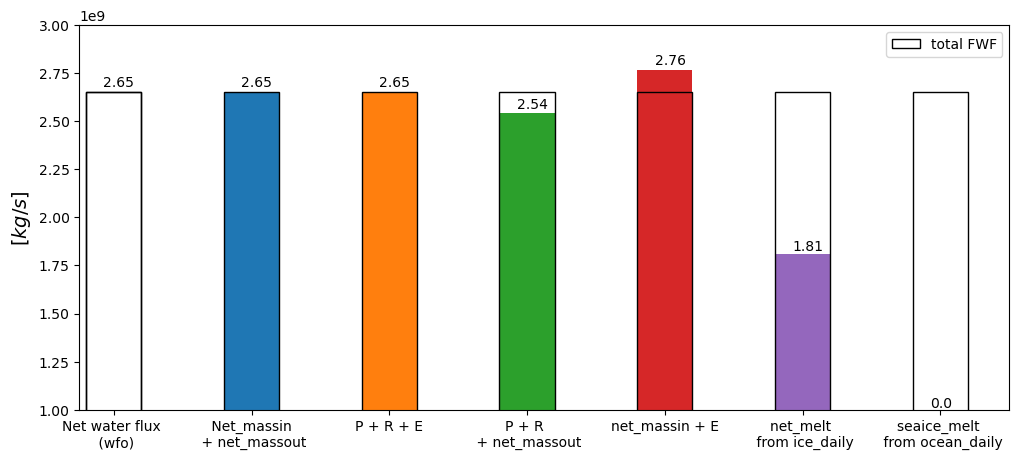

In [11]:
plt.figure(figsize=(12,5))

plt.bar([0],ocean_daily_int.wfo,color='none',edgecolor='k',label='total FWF') #Net surface water flux (precip+melt+lrunoff+ice calving-evap)
plt.bar([0,2,4,6,8,10,12],[ocean_daily_int.wfo,ocean_daily_int.wfo,ocean_daily_int.wfo,\
                           ocean_daily_int.wfo,ocean_daily_int.wfo,ocean_daily_int.wfo,ocean_daily_int.wfo],color='none',edgecolor='k',zorder=30) 
plt.text(-.15,ocean_daily_int.wfo*1.01,str(np.round(ocean_daily_int.wfo.values/1e9,2)))

plt.bar([2],wfo_from_decomp0); plt.text(-.15+2,ocean_daily_int.wfo*1.01,str(np.round(wfo_from_decomp0.values/1e9,2)))
plt.bar([4],wfo_from_decomp2); plt.text(-.15+4,wfo_from_decomp2*1.01,str(np.round(wfo_from_decomp2.values/1e9,2)))
plt.bar([6],wfo_from_decomp1) ; plt.text(-.15+6,wfo_from_decomp1*1.01,str(np.round(wfo_from_decomp1.values/1e9,2)))
plt.bar([8],wfo_from_decomp3) ; plt.text(-.15+8,wfo_from_decomp3*1.01,str(np.round(wfo_from_decomp3.values/1e9,2)))
plt.bar([10],Sea_ice_FM ); plt.text(-.15+10,Sea_ice_FM*1.01,str(np.round(Sea_ice_FM.values/1e9,2))) #Sea ice FM fluxes from ice_daily fields
plt.bar([12],SImelt_ocean_daily); plt.text(-.15+12,1.01e9,str(np.round(SImelt_ocean_daily.values/1e9,2))) #Sea ice FM fluxes from ocean_daily fields
plt.xticks(ticks=[0,2,4,6,8,10,12],labels=['Net water flux \n (wfo)',' Net_massin \n + net_massout', 'P + R + E','P + R \n + net_massout',\
                                  'net_massin + E','net_melt \n from ice_daily','seaice_melt \n from ocean_daily'])
plt.ylabel(r'[$kg/s$]',fontsize=14)
plt.xlim(-0.5,13)
plt.ylim(1e9,0.3e10)
plt.legend()
#plt.yscale('symlog')
#plt.grid(True, zorder=0)

The plot above + the fact that sea ice melt variable (seaice_melt) is zero all over, makes me think that the wfo is just P + R - E.

What is the rest from net_massin?

In [56]:
ocean_daily.precip

<xarray.DataArray 'precip' (time: 1, yh: 845, xh: 3600)> Size: 12MB
[3042000 values with dtype=float32]
Coordinates:
  * time     (time) object 8B 2001-01-01 12:00:00
  * yh       (yh) float64 7kB -81.11 -81.07 -81.02 ... -37.3 -37.22 -37.14
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
Attributes:
    units:          kg m-2 s-1
    long_name:      Liquid + frozen precipitation into ocean
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT

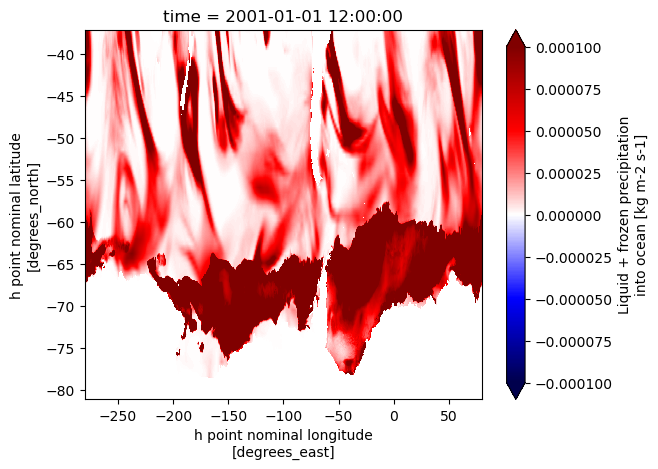

In [61]:
ocean_daily.precip.isel(time=0).plot(vmin=-0.0001,vmax=0.0001,cmap='seismic')

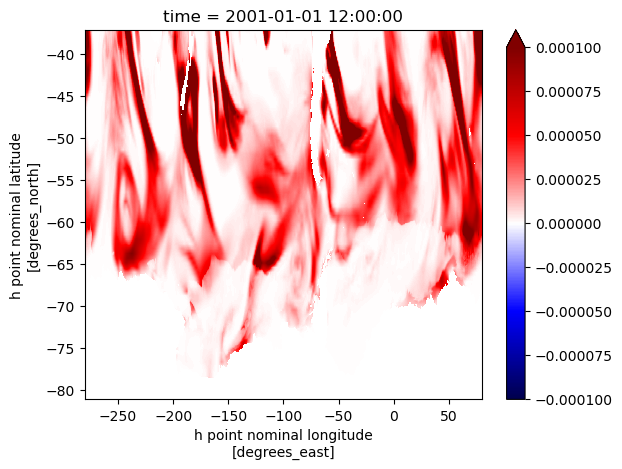

In [62]:
(ocean_daily.precip.isel(time=0) - net_melt_OceanGrid.isel(time=0)).plot(vmin=-0.0001,vmax=0.0001,cmap='seismic')

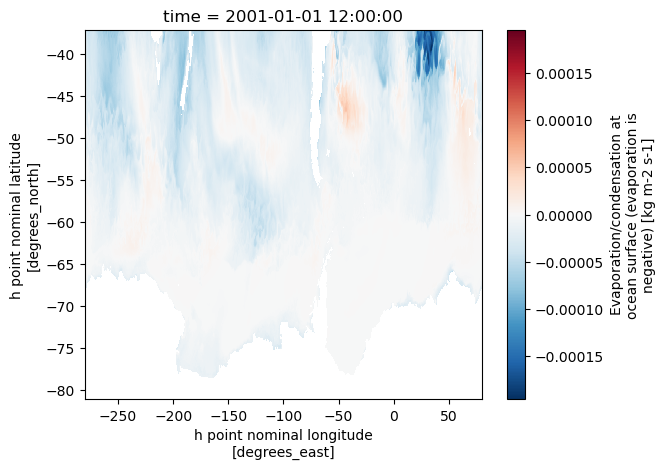

In [50]:
ocean_daily.evap.isel(time=0).plot()

In [41]:
# ocean_daily.seaice_melt.isel(time=0).plot()

Text(0.5, 1.0, 'Net_massout - E')

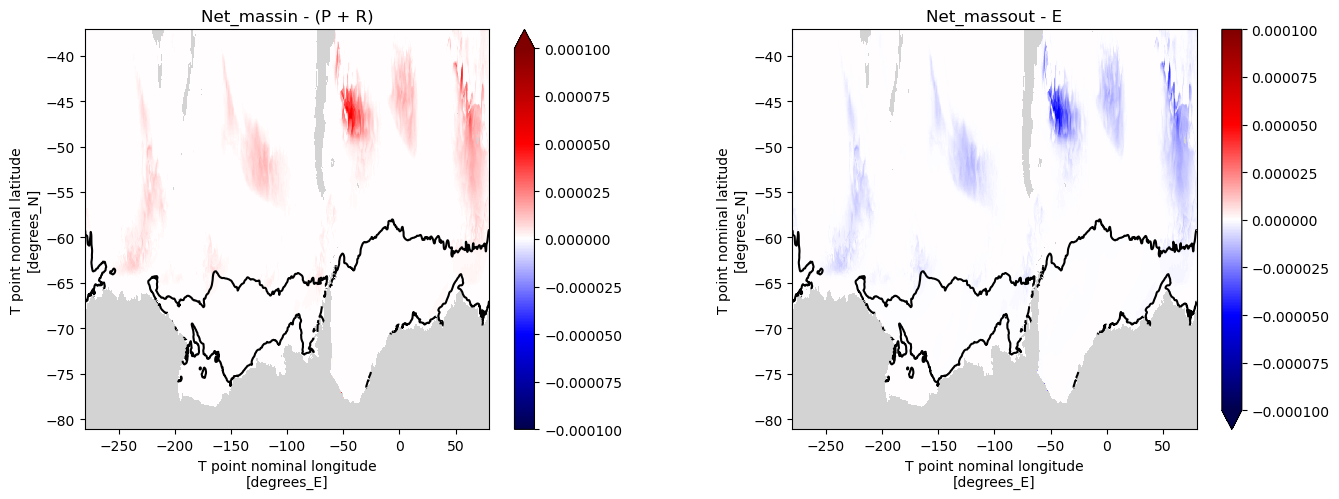

In [12]:
plt.figure(figsize=(24,5))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.4, hspace=0.4) 


ax0 = plt.subplot(1,3,1)
Massin_minus_PR.isel(time=0).plot(vmin=-1e-4,vmax=1e-4,cmap='seismic')
ax0.set_facecolor("lightgrey")
ice_daily.siconc.isel(time=0).plot.contour(levels=[0.15,],colors='k',add_colorbar=False)
plt.title('Net_massin - (P + R)')

ax1 = plt.subplot(1,3,2)
Massout_minus_E.isel(time=0).plot(vmin=-1e-4,vmax=1e-4,cmap='seismic')
ice_daily.siconc.isel(time=0).plot.contour(levels=[0.15,],colors='k',add_colorbar=False)
ax1.set_facecolor("lightgrey")
plt.title('Net_massout - E')

# ax2 = plt.subplot(1,3,3)
# ocean_daily.salt_flux_added.isel(time=0).plot(vmin=-5e-6,vmax=5e-6,cmap='seismic')
# Massin_minus_PR.isel(time=0).plot.contour(levels=[0,],colors='grey',linewidths=0.5)
# ax2.set_facecolor("lightgrey")

In [33]:
ocean_daily_int

<xarray.Dataset> Size: 38kB
Dimensions:                  (nv: 2, zi: 76, xq: 3601, yq: 846, zl: 75)
Coordinates:
  * nv                       (nv) float64 16B 1.0 2.0
  * zi                       (zi) float64 608B 0.0 1.083 ... 5.61e+03 6e+03
  * xq                       (xq) float64 29kB -280.0 -279.9 ... 79.9 80.0
  * yq                       (yq) float64 7kB -81.13 -81.09 ... -37.18 -37.1
  * zl                       (zl) float64 600B 0.5413 1.681 ... 5.805e+03
Data variables: (12/52)
    wfo                      float32 4B 2.653e+09
    evap                     float32 4B -1.402e+09
    seaice_melt              float32 4B 0.0
    precip                   float32 4B 3.95e+09
    vprec                    float32 4B 0.0
    frunoff                  float32 4B 0.0
    ...                       ...
    temp_int                 float32 4B 6.863e+20
    T_advection_xy_2d        float32 4B 5.603e+14
    Th_tendency_2d           float32 4B 8.432e+15
    volcello                 (zl) float32 300B 4.445e+21 4.912e+21 ... 7.077e+21
    zos                      float32 4B 1.016e+06
    mlotst                   float32 4B 2.239e+15

In [32]:
ocean_daily

<xarray.Dataset> Size: 3GB
Dimensions:                                (time: 1, yh: 845, xh: 3600,
                                            scalar_axis: 1, zi: 76, xq: 3601,
                                            yq: 846, zl: 75, nv: 2)
Coordinates:
  * time                                   (time) object 8B 2001-01-01 12:00:00
  * yh                                     (yh) float64 7kB -81.11 ... -37.14
  * xh                                     (xh) float64 29kB -279.9 ... 79.95
  * scalar_axis                            (scalar_axis) float64 8B 0.0
  * zi                                     (zi) float64 608B 0.0 1.083 ... 6e+03
  * xq                                     (xq) float64 29kB -280.0 ... 80.0
  * yq                                     (yq) float64 7kB -81.13 ... -37.1
  * zl                                     (zl) float64 600B 0.5413 ... 5.805...
  * nv                                     (nv) float64 16B 1.0 2.0
Data variables: (12/66)
    wfo                                    (time, yh, xh) float32 12MB ...
    evap                                   (time, yh, xh) float32 12MB ...
    seaice_melt                            (time, yh, xh) float32 12MB ...
    precip                                 (time, yh, xh) float32 12MB ...
    vprec                                  (time, yh, xh) float32 12MB ...
    frunoff                                (time, yh, xh) float32 12MB ...
    ...                                     ...
    T_adx_2d                               (time, yh, xq) float32 12MB ...
    T_ady_2d                               (time, yq, xh) float32 12MB ...
    average_T1                             (time) datetime64[ns] 8B ...
    average_T2                             (time) datetime64[ns] 8B ...
    average_DT                             (time) timedelta64[ns] 8B ...
    time_bnds                              (time, nv) timedelta64[ns] 16B ...
Attributes:
    NumFilesInSet:     1
    title:             panan
    associated_files:  areacello: 20010101.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A

Text(0.5, 1.0, 'Freshwater flux from sea ice')

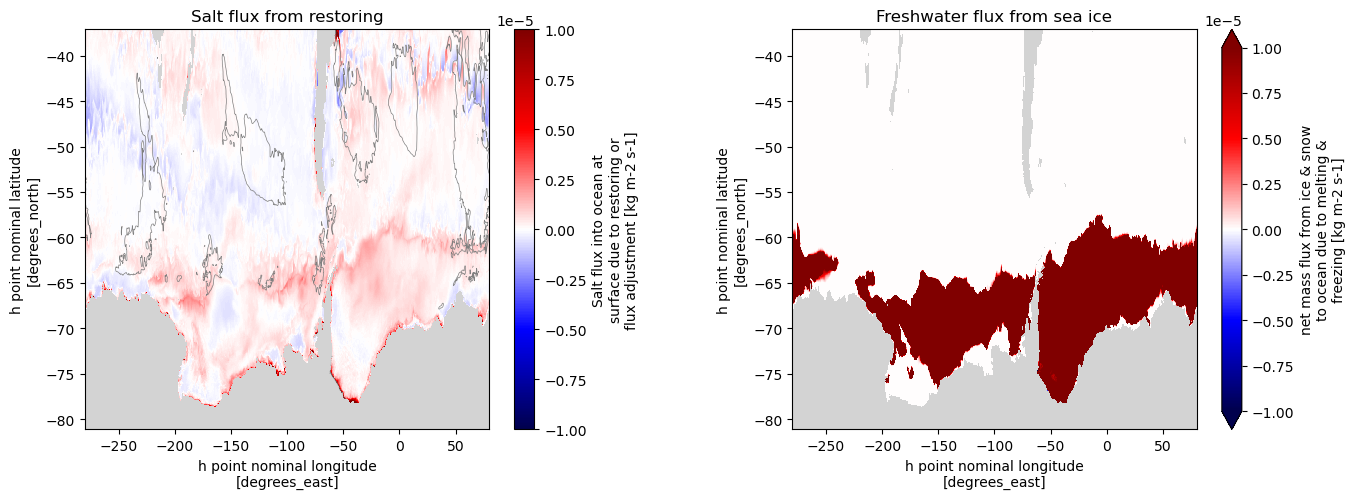

In [13]:
plt.figure(figsize=(24,5))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.4, hspace=0.4) 


ax0 = plt.subplot(1,3,1)
ocean_daily.salt_flux_added.isel(time=0).plot(vmin=-1e-5,vmax=1e-5,cmap='seismic')
Massin_minus_PR.isel(time=0).plot.contour(levels=[0.2e-5,],colors='grey',linewidths=0.5)
ax0.set_facecolor("lightgrey")
plt.title('Salt flux from restoring')

ax1 = plt.subplot(1,3,2)
net_melt_OceanGrid.isel(time=0).plot(vmin=-1e-5,vmax=1e-5,cmap='seismic')
ax1.set_facecolor("lightgrey")
plt.title('Freshwater flux from sea ice')

These rests in net_mass_in and net_massout are largely compensating each other and seem to be very much away from sea ice, so it couldnt be sea ice fluxes. To be honest, I'm not quite sure what these rests are. But, as far as we know, $P+R+E \ = \ wfo$

This means the wfo currently dont take into account restoring fluxes orsea ice fluxes

 It is probably worth to take into account when doing the SWMT formula, and update for the surface freshwater fluxes to be
$$
Total\ FWF = wfo \ + \ net\_melt - (1000*salt\_flux\_added/AS)
$$

where *AS* is the absolute salinity, and *net\_melt* derives from the sea ice model

In [14]:
total_FWF_norestore = ocean_daily_int.wfo + Sea_ice_FM
total_FWF_withrestore = ocean_daily_int.wfo + Sea_ice_FM - FWF_restore

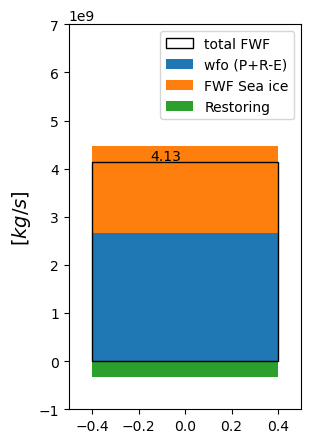

In [15]:
plt.figure(figsize=(3,5))

plt.bar([0],total_FWF_withrestore,color='none',edgecolor='k',zorder=4,label='total FWF') #Net surface water flux (precip+melt+lrunoff+ice calving-evap)
plt.text(-.15,total_FWF_withrestore*1.01,str(np.round(total_FWF_withrestore.values/1e9,2)))

plt.bar([0],ocean_daily_int.wfo,label='wfo (P+R-E)',zorder=2)
plt.bar([0],ocean_daily_int.wfo+Sea_ice_FM,label='FWF Sea ice',zorder=1)
plt.bar([0],-FWF_restore,label='Restoring',zorder=0)
plt.ylabel(r'[$kg/s$]',fontsize=14)
plt.xlim(-0.5,0.5)
plt.ylim(-1e9,0.7e10)
plt.legend()


Based on this analysis, the freshwater fluxes we want to save for SWMT are:

*wfo*, *salt_flux_added*, *sos* and *net_melt* (in ice_daily)

These should be enough for sea ice fluxes analysis too, with one caveat that I could not find a variable that separates sea ice melting to sea ice freezing

### Heat fluxes balance

In [16]:
# ocean_daily_int.hfds is Surface ocean heat flux from SW+LW+lat+sens+mass transfer+frazil+restore+seaice_melt_heat or flux adjustments
#lets reconstitute it offline
HF_offline = ocean_daily_int.SW + ocean_daily_int.LW + ocean_daily_int.latent + ocean_daily_int.sensible + ocean_daily_int.Heat_PmE + ocean_daily_int.frazil
ocean_daily_int.hfds,HF_offline

(<xarray.DataArray 'hfds' ()> Size: 4B
 array(7.871671e+15, dtype=float32),
 <xarray.DataArray ()> Size: 4B
 array(7.8716824e+15, dtype=float32))

here some other variables are 0's:

*seaice_melt_heat*



In [17]:
ocean_daily_int

<xarray.Dataset> Size: 38kB
Dimensions:                  (nv: 2, zi: 76, xq: 3601, yq: 846, zl: 75)
Coordinates:
  * nv                       (nv) float64 16B 1.0 2.0
  * zi                       (zi) float64 608B 0.0 1.083 ... 5.61e+03 6e+03
  * xq                       (xq) float64 29kB -280.0 -279.9 ... 79.9 80.0
  * yq                       (yq) float64 7kB -81.13 -81.09 ... -37.18 -37.1
  * zl                       (zl) float64 600B 0.5413 1.681 ... 5.805e+03
Data variables: (12/52)
    wfo                      float32 4B 2.653e+09
    evap                     float32 4B -1.402e+09
    seaice_melt              float32 4B 0.0
    precip                   float32 4B 3.95e+09
    vprec                    float32 4B 0.0
    frunoff                  float32 4B 0.0
    ...                       ...
    temp_int                 float32 4B 6.863e+20
    T_advection_xy_2d        float32 4B 5.603e+14
    Th_tendency_2d           float32 4B 8.432e+15
    volcello                 (zl) float32 300B 4.445e+21 4.912e+21 ... 7.077e+21
    zos                      float32 4B 1.016e+06
    mlotst                   float32 4B 2.239e+15

In [18]:
ocean_daily_int.hfds,HF_offline

(<xarray.DataArray 'hfds' ()> Size: 4B
 array(7.871671e+15, dtype=float32),
 <xarray.DataArray ()> Size: 4B
 array(7.8716824e+15, dtype=float32))

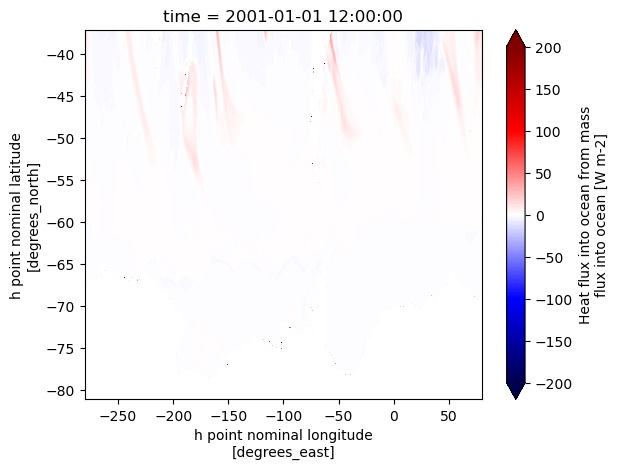

In [68]:
ocean_daily.Heat_PmE.isel(time=0).plot(vmin=-200,vmax=200,cmap='seismic')

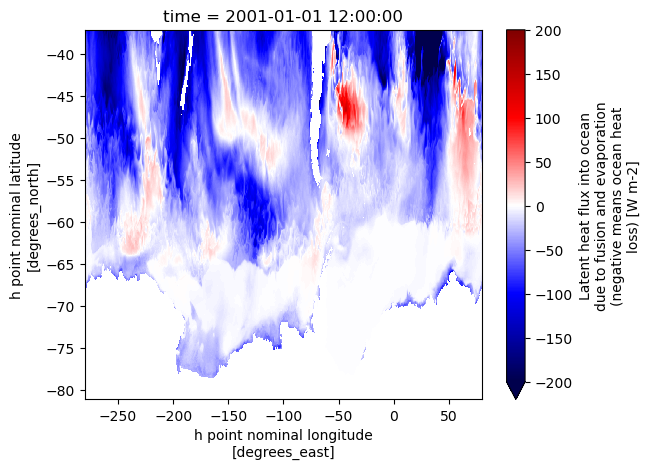

In [69]:
ocean_daily.latent.isel(time=0).plot(vmin=-200,vmax=200,cmap='seismic')

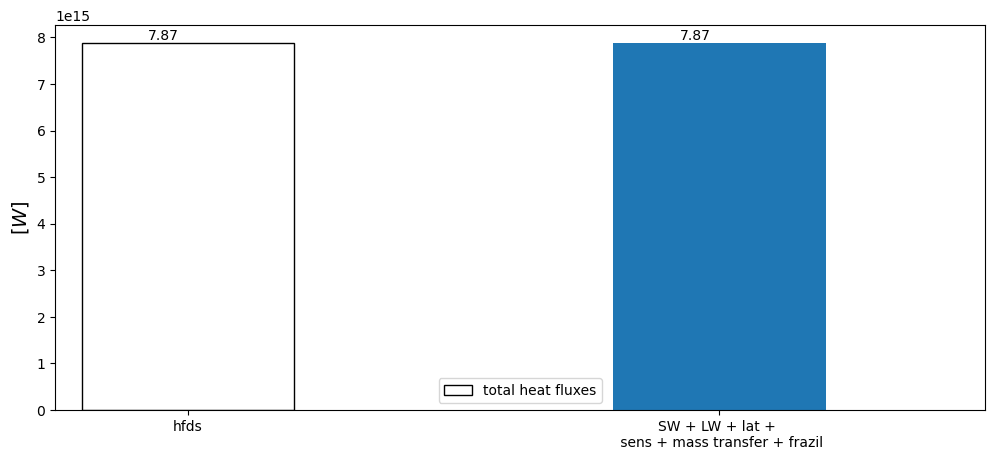

In [19]:
plt.figure(figsize=(12,5))

plt.bar([0],ocean_daily_int.hfds,color='none',edgecolor='k',label='total heat fluxes') #ocean_daily_int.hfds is Surface ocean heat flux from SW+LW+lat+sens+mass transfer+frazil+restore+seaice_melt_heat or flux adjustments
plt.text(-.15,ocean_daily_int.hfds*1.01,str(np.round(ocean_daily_int.hfds.values/1e15,2)))

plt.bar([2],HF_offline); plt.text(-.15+2,HF_offline*1.01,str(np.round(HF_offline.values/1e15,2)),label = 'offline sum')
plt.xticks(ticks=[0,2],labels=['hfds','SW + LW + lat + \n sens + mass transfer + frazil'])
plt.ylabel(r'[$W$]',fontsize=14)
plt.xlim(-0.5,3)
plt.legend()


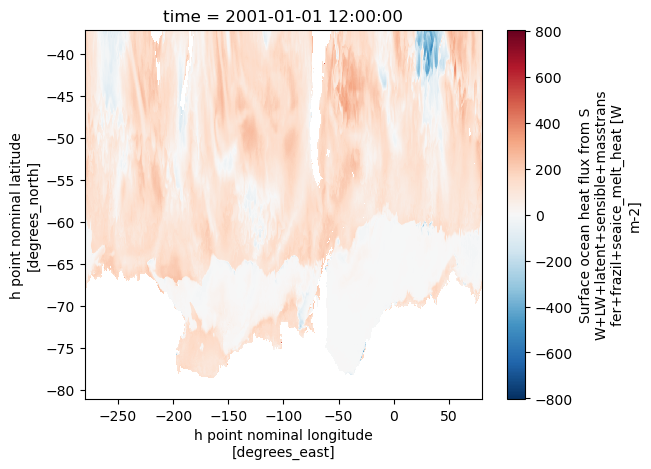

In [20]:
ocean_daily.hfds.isel(time=0).plot()

In [21]:
ice_daily.BHEAT

<xarray.DataArray 'BHEAT' (time: 2, yT: 845, xT: 3600)> Size: 24MB
[6084000 values with dtype=float32]
Coordinates:
  * time     (time) object 16B 2001-01-01 12:00:00 2001-01-02 12:00:00
  * yT       (yT) float64 7kB -81.11 -81.07 -81.02 ... -37.3 -37.22 -37.14
  * xT       (xT) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
Attributes:
    units:          W/m^2
    long_name:      ocean to ice heat flux
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

Text(0.5, 1.0, 'ocean to ice heat flux')

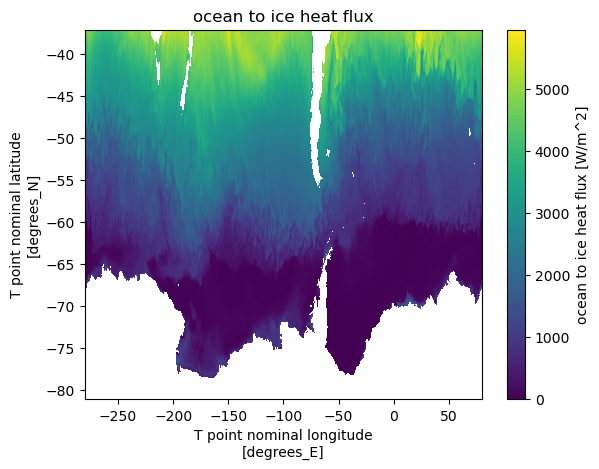

In [22]:
ice_daily.BHEAT.isel(time=0).plot()
plt.title(ice_daily.BHEAT.long_name)

In [54]:
ocean_daily.siconc

AttributeError: 'Dataset' object has no attribute 'siconc'

Text(0.5, 1.0, 'heat needed to melt ice')

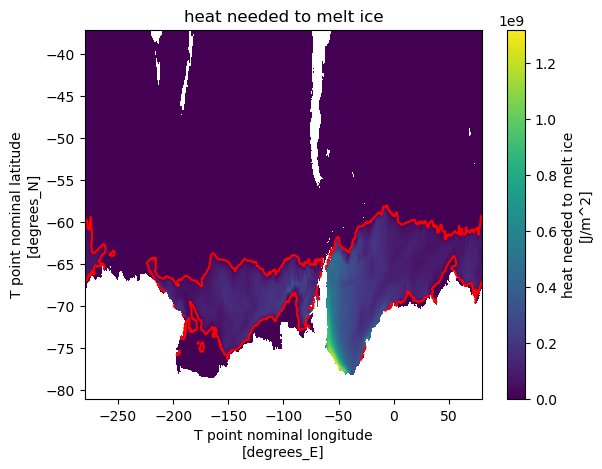

In [23]:
ice_daily.E2MELT.isel(time=0).plot() # heat needed to melt ice [J/m2] # Maybe it is integrated in the model timelength
ice_daily.siconc.isel(time=0).plot.contour(levels=[0.15,],colors='r',add_colorbar=False)
plt.title(ice_daily.E2MELT.long_name)

In [24]:
(ice_daily.E2MELT.isel(time=0) * areacello_SI).sum(('xT','yT'))/(24*60*60)

<xarray.DataArray ()> Size: 8B
array(2.05455981e+16)
Coordinates:
    time     object 8B 2001-01-01 12:00:00

Text(0.5, 1.0, 'bottom surface melting energy flux')

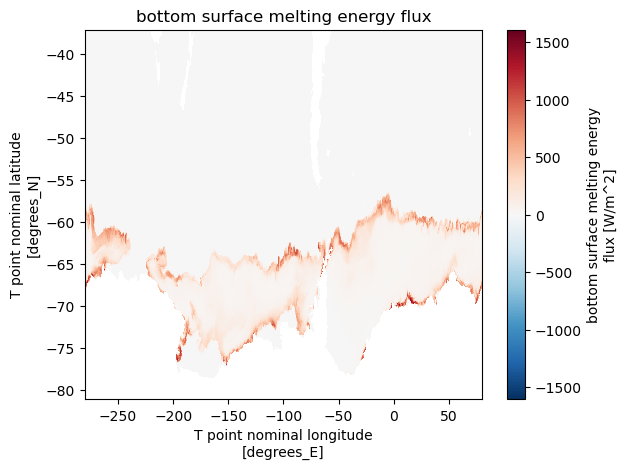

In [25]:
#Bmelt
ice_daily.BMELT.isel(time=0).plot()
plt.title(ice_daily.BMELT.long_name)

In [26]:
(ice_daily.BMELT * areacello_SI).sum(('xT','yT'))

<xarray.DataArray (time: 2)> Size: 8B
array([2.2899609e+15, 2.2579413e+15], dtype=float32)
Coordinates:
  * time     (time) object 16B 2001-01-01 12:00:00 2001-01-02 12:00:00

In [27]:
(ice_daily.TMELT.isel(time=0) * areacello_SI).sum(('xT','yT'))

<xarray.DataArray ()> Size: 4B
array(8.418556e+13, dtype=float32)
Coordinates:
    time     object 8B 2001-01-01 12:00:00

Based on this so far, I think to diagnose heat fluxes to sea ice, I'd neet to save:

*hfds*,*BMELT*,*TMELT*,*frazil*


Adittionally, it would be useful to save vertically intergrated daily ocean heat transports for high frequency eddy decomposition of heat rtansport in different areas of the SO


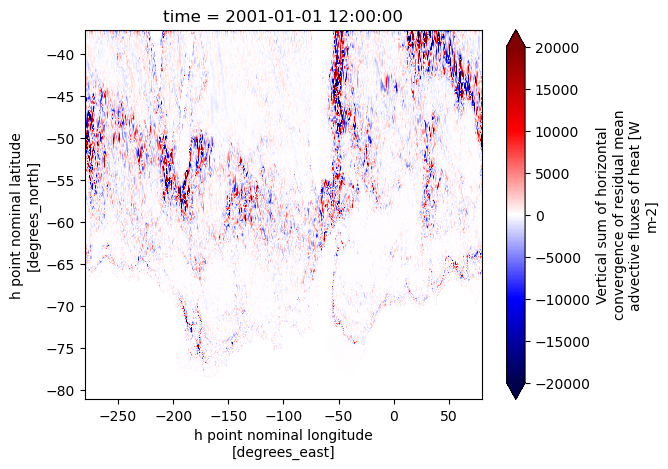

In [28]:
ocean_daily.T_advection_xy_2d.isel(time=0).plot(vmin=-20000,vmax=20000,cmap='seismic')

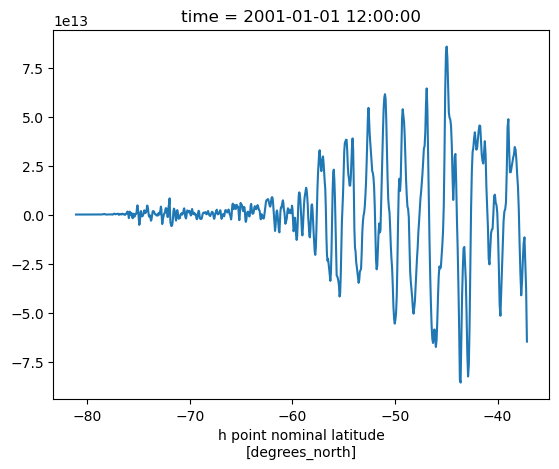

In [29]:
(ocean_daily.T_advection_xy_2d.isel(time=0) *ocean_static.areacello).sum('xh').plot()

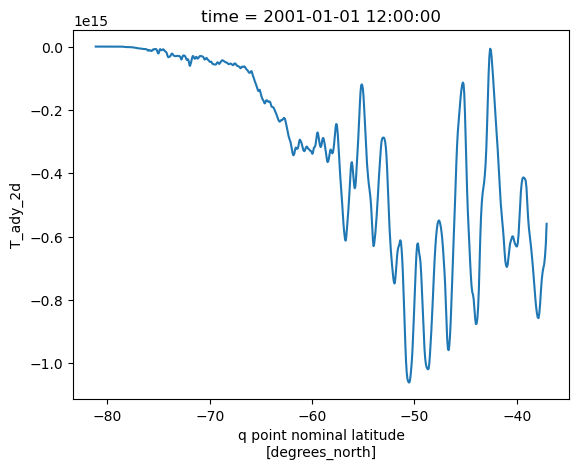

In [30]:
ocean_daily.T_ady_2d.isel(time=0).sum('xh').plot()